# Прикладные задачи машинного обучения, DS-поток
## Задание 2

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Выполненную работу нужно отправить телеграм-боту `@miptstats_ds24_bot`. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания получат штраф.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.


**Правила оформления теоретических задач:**

* Решения необходимо прислать одним из следующих способов:
  * фотографией в правильной ориентации, где все четко видно, а почерк разборчив,
    * отправив ее как файл боту вместе с ноутбуком *или*
    * вставив ее в ноутбук посредством `Edit -> Insert Image` (<font color="red">фото, вставленные ссылкой, не принимаются</font>);
  * в виде $\LaTeX$ в markdown-ячейках.
* Решения не проверяются, если какое-то требование не выполнено. Особенно внимательно все проверьте в случае выбора второго пункта (вставки фото в ноутбук). <font color="red"><b>Неправильно вставленные фотографии могут не передаться при отправке.</b></font> Для проверки попробуйте переместить `ipynb` в другую папку и открыть его там.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.



**Баллы за задание:**

* Задача 1 &mdash; 15 балл
* Задача 2 &mdash; 40 балла
* Задача 3 &mdash; 150 баллов

-----------

In [1]:
# Bot check

# HW_ID: ds_ml2_2
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [2]:
# import sys, os
# if 'google.colab' in sys.modules:
#     !pip install swig 'gymnasium[all]' pyglet pygame
#     !apt-get install -y xvfb python-opengl > /dev/null 2>&1
#     !pip install pyvirtualdisplay > /dev/null 2>&1

#     from pyvirtualdisplay import Display
#     display = Display(visible=0, size=(400, 300))
#     display.start()

# # This code creates a virtual display to draw game images on.
# # If you are running locally, just ignore it
# if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
#     !bash ../xvfb start
#     os.environ['DISPLAY'] = ':1'


In [3]:
import gc
import math
import random
from collections import defaultdict, deque

import gymnasium as gym
import gymnasium.envs.toy_text
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as sps
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython import display
from IPython.display import clear_output
from pandas import DataFrame

from tqdm.auto import tqdm


sns.set_theme(style='darkgrid', font_scale=1.5, palette='Set2')

---
### Задача 1.
На рисунке показан марковский процесс принятия решений, описывающий поведение среды. Распределение награды на каждом шаге обозначено желтыми стрелками, если стрелка отсутствует &mdash; награда нулевая, иначе &mdash; в соответствии со значением.


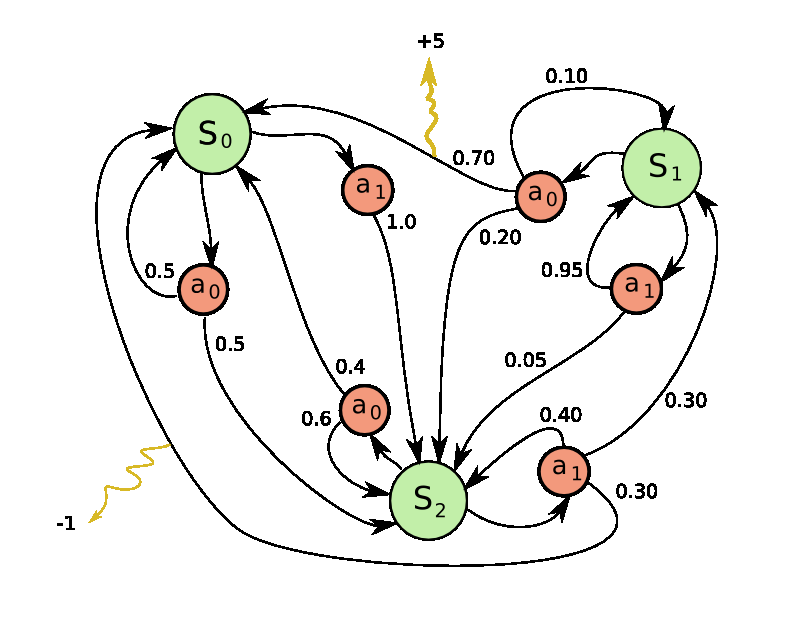

Агент играет со средой, используя поведение Q-learning, $\gamma=0.5, \alpha=0.9$. Значения $Q$ в момент времени $t$ даны в таблице. Известно, что в текущий момент времени агент находился в состоянии $S_1$; подействовав на среду, агент получил награду $+5$ и перешел в состояние $S_0$. Как изменятся $Q$ значения агента?
    
| $Q$   | $a_0$ | $a_1$ |
|-------|------:|-------|
| $s_0$ | 2     | 3     |
| $s_1$ | 4     | 2     |
| $s_2$ | 2     | -1    |


$\square$

$Q(s_1, a_0) = Q(s_1, a_0) + \alpha (r_{t} + \gamma\cdot Q(s_0, a_1) - Q(s_1, a_0))=4 + 0.9 \cdot(5 + \gamma \cdot (3) - 4) = 6.25$

В итоге таблица станет такой:

| $Q$   | $a_0$ | $a_1$ |
|-------|------:|-------|
| $s_0$ | 2     | 3     |
| $s_1$ | 6.25     | 2     |
| $s_2$ | 2     | -1    |

$\blacksquare$

---
### Задача 2.

#### 2.1 Контрпример

Приведите пример функции $f$ и распределений $P$ и $Q$, таких что
$$
\operatorname{E}_P f^2(X) \frac{p(X)}{q(X)} < \operatorname{E}_P f^2(X).
$$

*Замечание*: можно привести пример дискретного распределения.

#### 2.2 RL-политики

Пусть $\pi$ и $\mu$ &mdash; две политики в среде, в которой каждая игра длится ровно $T$ действий агента. Обозначим
* $\tau$ &mdash; траектория в среде;
* $p_\pi$, $p_\mu$ &mdash; дискретные или непрерывные плотности на *траекториях* при использовании агентом политик $\pi$ и $\mu$ соответственно;
* $\operatorname{E}_\pi$ и $\operatorname{E}_\mu$ &mdash; матожидания по *траекториям*, полученным при использовании политик $\pi$ и $\mu$ соответственно;
* $P^\pi_t$ распределение на $s_t$ для агента при использовании политики $\pi$ (то есть распределение на состоянии в момент времени $t$).

Докажите, что
$$
\operatorname{E}_\pi \frac{p_\pi(\tau)}{p_\mu(\tau)} \geq \prod_{t=1}^T \exp \left( \operatorname{E}_{s_t \sim P^\pi_t} KL \left( \pi \left(\cdot | s_t\right) , \mu \left(\cdot | s_t\right) \right) \right)
$$

*Подсказка*: воспользуйтесь неравенством Йенсена.

**Сделайте выводы** о дисперсии оценки value-функции с помощью importance sampling.

$\square$

## СМ PDF

$\blacksquare$

**Выводы:** Как видим, мат. ожидание отношения распределений тем больше, чем сильнее различаются распределения. Это закономерно ведет к увелечению дисперсии value-функции.

---
### Задача 3.
#### 3.1 Табличные агенты

Ваша задача заполнить пропуски в коде ниже и в итоге написать 3 агента: SARSA, EVSARSA, Q-learning.


Для начала напишем общий класс SARSA, EVSARSA и Q-learning, используя TD подход и $\varepsilon$-greedy стратегию выбора действия. Подробнее про теорию можно почитать в лекции или в семинаре.


`AgentClass` &mdash; класс, который реализует общие функции для всех 3 агентов, а именно:

* `get_qvalue` &mdash; получить текущее значение $Q$,
* `set_qvalue` &mdash; изменить текущее значение $Q$ на новое,
* `update` &mdash; обновление значений $Q$ агента по формуле

$$
    Q(s_t, a_t) = (1-\alpha) Q(s_t, a_t) + \alpha(r_t + \gamma V(s_{t + 1})),
$$
* `get_best_action` &mdash; получить наилучшее действие, исходя из значений Q,
* `get_action` &mdash; выбор текущего действия агентом исходя из $\varepsilon$-greedy стратегии.

Формула обновления:

In [4]:
class AgentClass:
    def __init__(self, alpha, epsilon, discount, n_actions):
        """
        Инициализация агента.

        :param alpha: параметр для скользящего среднего
        :param epsilon: для epsilon-greedy стратегии
        :param discount: гамма в функции награды,
                         с каким весом оценивает будущие награды агент
        :param n_actions: количество возможных действий
        """

        self.n_actions = n_actions
        self._qvalues = defaultdict(lambda: defaultdict(lambda: 0))
        self.alpha = alpha
        self.epsilon = epsilon
        self.discount = discount

    def get_qvalue(self, state, action):
        """
        Возвращает Q(state,action).

        :param state: состояние среды
        :param action: действие (индекс)

        :return: Q(state,action)
        """

        return self._qvalues[state][action]

    def set_qvalue(self, state, action, value):
        """
        Изменяет значение в Q(state, action) на value.

        :param state: состояние среды
        :param action: действие (индекс)
        :param value: новое значение
        """

        self._qvalues[state][action] = value

    def update(self, state, action, reward, next_state, is_done):
        """
        Обновляет текущее Q
        Формула обновления:
            TD = r + gamma * V(s')
            Q(s,a) := (1 - alpha) * Q(s,a) + alpha * TD.
        Если это финальное состояние в среде, то
            TD = r.

        :param state: состояние среды
        :param action: действие (индекс)
        :param reward: награда
        :param next_state: следующее состояние
        :param is_done: финальное ли состояние next_state
        """

        gamma = self.discount
        learning_rate = self.alpha

        TD = reward + gamma * self.get_value(next_state)
        if is_done:
            TD = reward
        qval = (1 - self.alpha) * self.get_qvalue(state, action) + self.alpha * TD

        self.set_qvalue(state, action, qval)

    def get_value(self, state):
        """
        Своя функция для каждого из алгоритмов.

        :param state: состояние среды

        :return: оценка V(s)
        """

        raise Exception("Not implemented")

    def get_best_action(self, state):
        """
        Найти наилучшее действия из state.
        Вернуть argmax_{a}Q(s, a).

        :param state: состояние среды

        :return: argmax_{a}Q(s, a)
        """

        possible_actions = range(self.n_actions)
        qvals = [self.get_qvalue(state, action) for action in possible_actions]
        best_action = possible_actions[np.argmax(qvals)]
        return best_action

    def get_action(self, state):
        """
        Функция для выбора действия, котороре сейчас совершит агент.

        С вероятностью epsilon каждое действие выбирается равновероятно.
        С вероятностью 1 - epsilon выбирается наилучшее действие, исходя из Q.

        :param state: состояние среды

        :return: семплированное действие
        """

        epsilon = self.epsilon

        if np.random.random() < (1 - epsilon):
            return self.get_best_action(state)
        else:
            return np.random.randint(0, self.n_actions)

    def policy(self, state, action):
        return (1 - self.epsilon) * (
            action == self.get_best_action(state)
        ) + self.epsilon / self.n_actions

    def policy_softmax(self, state, action, tau=1.0):
        qvals = np.array([self.get_qvalue(state, a) for a in range(self.n_actions)])
        qvals = qvals - np.max(qvals)
        exp_q = np.exp(qvals / tau)
        probs = exp_q / np.sum(exp_q)
        return probs[action]


    def get_action_softmax(self, state, tau=1.0):
        probs = np.array([self.policy_softmax(state, a, tau) for a in range(self.n_actions)])
        return np.random.choice(range(self.n_actions), p=probs)


Теперь реализуем классы-наследники для каждого из агентов Sarsa, EVSarsa, Q-learning.

В каждом из 3 классов надо дописать только функцию `get_value`, исходя из формул подсчета value-state функций в каждом из подходов.

*Напоминание:*

__SARSA__: $V(s) = Q(s, a),\ a \sim \pi(a|s).$

__EVSARSA__: $V(s) = \mathsf{E}_{a \sim \pi(a|s)}Q(s, a).$

__Q-learning__: $V(s) = \max_{a}Q(s, a).$

In [5]:
class SarsaAgent(AgentClass):

    def get_value(self, state):
        """
        Возвращает оценку V.
        Формула:
        V(s) = Q(s, a')

        :param state: состояние среды

        :return: оценка V(s)
        """

        chosen_action = self.get_best_action(state)
        
        return self.get_qvalue(state, chosen_action)


In [6]:
class EVSarsaAgent(AgentClass):

    def get_value(self, state):
        """
        Возвращает оценку V.
        Формула:
        V(s) = сумма по всем a_i: (pi(a_i | s) * Q(s, a_i)).

        :param state: состояние среды

        :return: оценка V(s)
        """

        # Ваш код
        state_value = np.sum(
            [
                self.policy(state, action) * self.get_qvalue(state, action)
                for action in range(self.n_actions)
            ]
        )
        return state_value

In [7]:
class QLearningAgent(AgentClass):

    def get_value(self, state):
        """
        Возвращает оценку V.
        Формула:
        V(s) = максимум по действиям Q(state,action).

        :param state: состояние среды

        :return: оценка V(s)
        """

        return np.max(
            [self.get_qvalue(state, action) for action in range(self.n_actions)]
        )

Теперь проверьте на среде Taxi, что ваши агенты обучились. Каждый агент должен получать награду в конце игры больше 5. Можете использовать код с семинара.


__Напоминание__

*Описание среды*:

На карте есть 4 точки. Задача агента состоит в том, чтобы подобрать человека из одного места и довезти его до другой точки. Агент получает 20 очков за выполненное задание и теряет по 1 очку за каждое действие. Если алгоритм попытается высадить или взять человека из неккоректной точки, то он теряет 10 очков.

/home/alexander/.venv/lib/python3.13/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


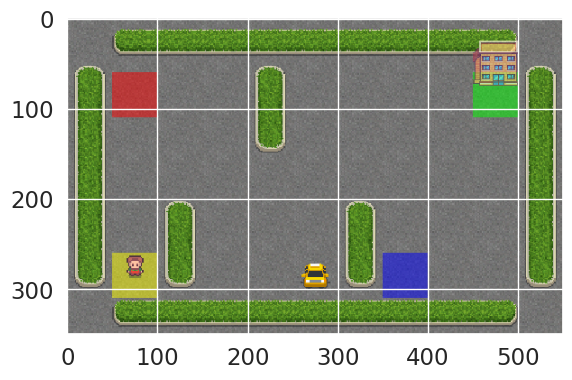

In [8]:
env = gym.make("Taxi-v3", render_mode='rgb_array')

n_actions = env.action_space.n

env.reset()
plt.imshow(env.render())

In [9]:
def play_and_train(env, agent, t_max=10**4, use_softmax=False, tau=1):
    """
    Функция для сыграния агентом одной игры в env и обучения во время игры агента.
    Возвращает итоговую награду агента в текущей сессии.
    """
    total_reward = 0.0
    s, _ = env.reset()

    for t in range(t_max):
        # Выбираем действие
        if use_softmax:
            a = agent.get_action_softmax(s, tau=tau)
        else:
            a = agent.get_action(s)

        # Забираем следующее состояние среды
        next_s, r, done, _, _ = env.step(a)

        # Обновляем Q-значения у агента
        agent.update(s, a, r, next_s, done)

        s = next_s
        total_reward += r
        # Если есть флаг окончания сессии - заканчиваем.
        if done:
            break

    return total_reward

In [10]:
sarsa_agent = SarsaAgent(alpha=0.5, epsilon=0.25, discount=0.99, n_actions=n_actions)

evsarsa_agent = EVSarsaAgent(
    alpha=0.5, epsilon=0.25, discount=0.99, n_actions=n_actions
)

qlearning_agent = QLearningAgent(
    alpha=0.5, epsilon=0.25, discount=0.99, n_actions=n_actions
)

SARSA: eps = 0.0 средняя награда = 7.6
EVSARSA: eps = 0.0 средняя награда = 8.2
Q-learning: eps = 0.0 средняя награда = 7.5


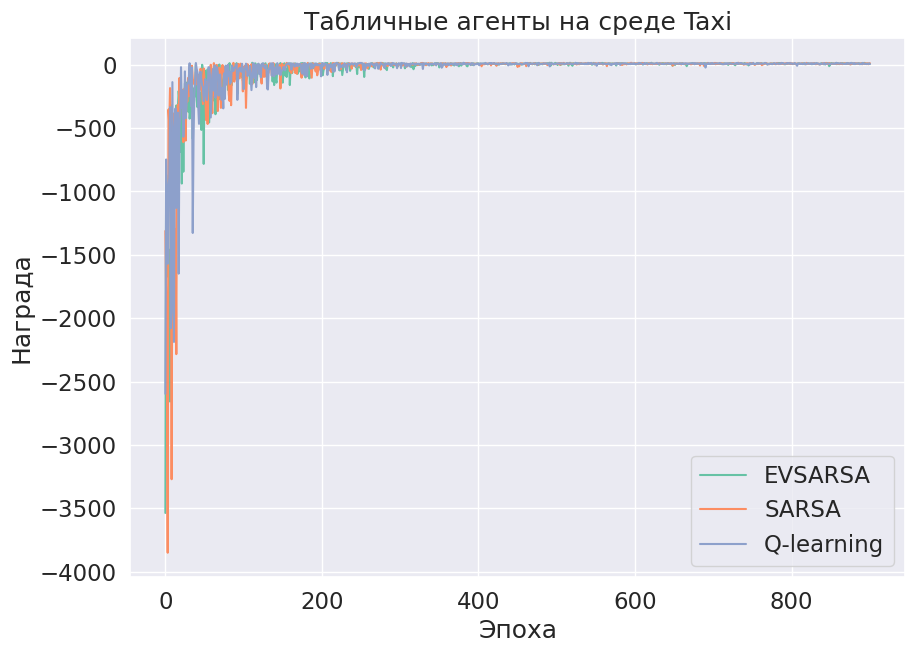

In [11]:
sarsa_rewards = []
evsarsa_rewards = []
qlearning_rewards = []

for i in tqdm(range(1000)):
    sarsa_rewards.append(play_and_train(env, sarsa_agent))
    evsarsa_rewards.append(play_and_train(env, evsarsa_agent))
    qlearning_rewards.append(play_and_train(env, qlearning_agent))

    sarsa_agent.epsilon *= 0.99
    evsarsa_agent.epsilon *= 0.99
    qlearning_agent.epsilon *= 0.99

    if i % 100 == 0:
        clear_output(True)
        print(
            "SARSA: eps =",
            round(sarsa_agent.epsilon, 3),
            "средняя награда =",
            np.mean(sarsa_rewards[-10:]),
        )
        print(
            "EVSARSA: eps =",
            round(evsarsa_agent.epsilon, 3),
            "средняя награда =",
            np.mean(evsarsa_rewards[-10:]),
        )
        print(
            "Q-learning: eps =",
            round(qlearning_agent.epsilon, 3),
            "средняя награда =",
            np.mean(qlearning_rewards[-10:]),
        )

        plt.figure(figsize=(10, 7))
        plt.title("Табличные агенты на среде Taxi")
        plt.plot(evsarsa_rewards, label="EVSARSA")
        plt.plot(sarsa_rewards, label="SARSA")
        plt.plot(qlearning_rewards, label="Q-learning")  # ← (3)
        plt.ylabel("Награда")
        plt.xlabel("Эпоха")
        plt.legend()
        plt.show()

#### 3.2 Gridworld Cliff среда


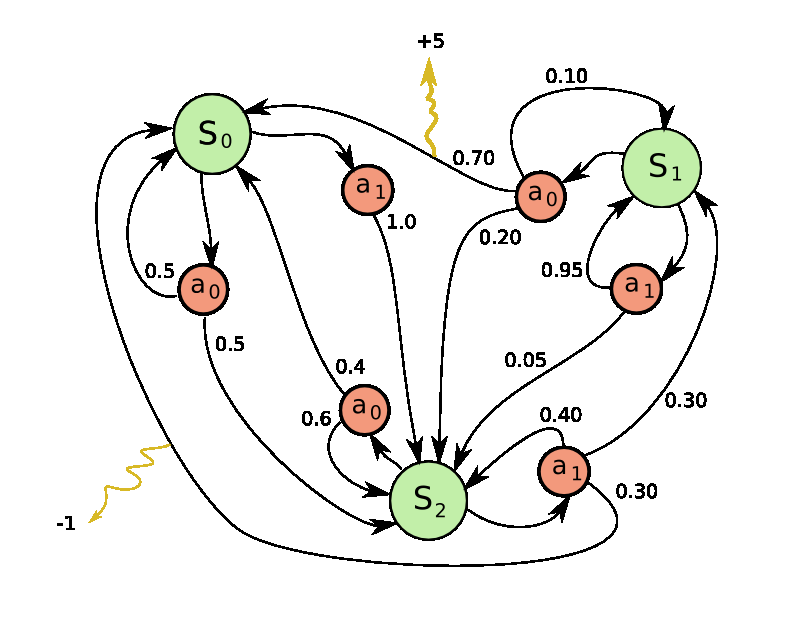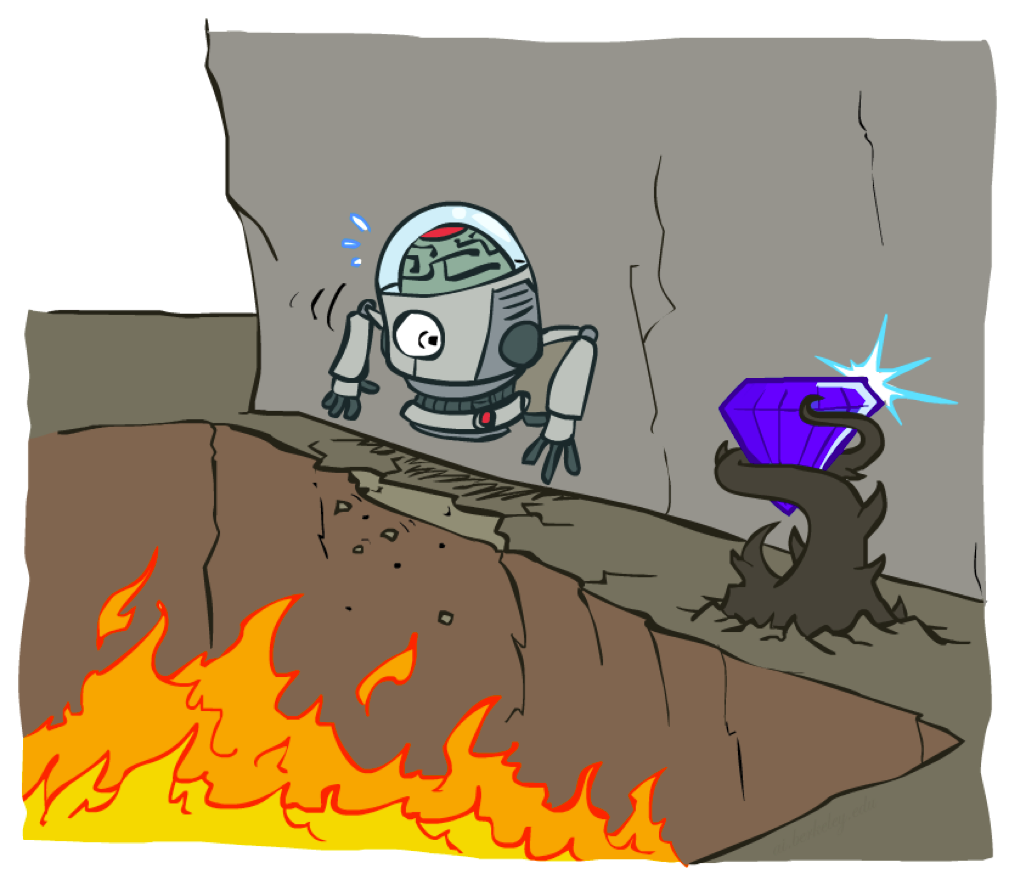

Данная среда представляет собой доску 4x12, внутри которой робот пытается найти сокровище.

В среде есть 4 вида клеток:
- `x` &mdash; стартовая клетка для робота,
- `T` &mdash; терминальная клетка с сокровищем,
- `o` &mdash; обычная клетка,
- `C` &mdash; клетка с ямой.

За каждое действие робот получает -1 награду, за попадание в яму получает -100 очков. У робота 4 варианта действий: вверх, вниз, вправо, влево. При этом среда детерминирована.

Посмотрим на нее визуально.  

In [12]:
env = gym.make("CliffWalking-v1", render_mode="ansi")
n_actions = env.action_space.n
env.reset()

print(env.render())

o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  C  C  C  C  C  C  C  C  C  C  T




Как видно, наибольшая награда в этой среде: -13 очков, если пройти строго над ямами.


Теперь проинициализируем агентов.

In [13]:
agent_evsarsa = EVSarsaAgent(alpha=0.25, epsilon=0.2, discount=0.99,
                             n_actions=n_actions)

agent_sarsa = SarsaAgent(alpha=0.25, epsilon=0.2, discount=0.99,
                         n_actions=n_actions)

agent_ql = QLearningAgent(alpha=0.25, epsilon=0.2, discount=0.99,
                          n_actions=n_actions)

Обучите агентов на этой среде.

In [14]:
def moving_average(x, span=100):
    """
    Функция для сглаживания кривой награды на графиках.

    :param x: сглаживаемый массив
    :param span: коэффициент затухания
    """

    return DataFrame({'x': np.asarray(x)}).x.ewm(span=span).mean().values


EVSARSA средняя награда = -25.02
SARSA средняя награда = -81.85
QLEARNING средняя награда = -91.31


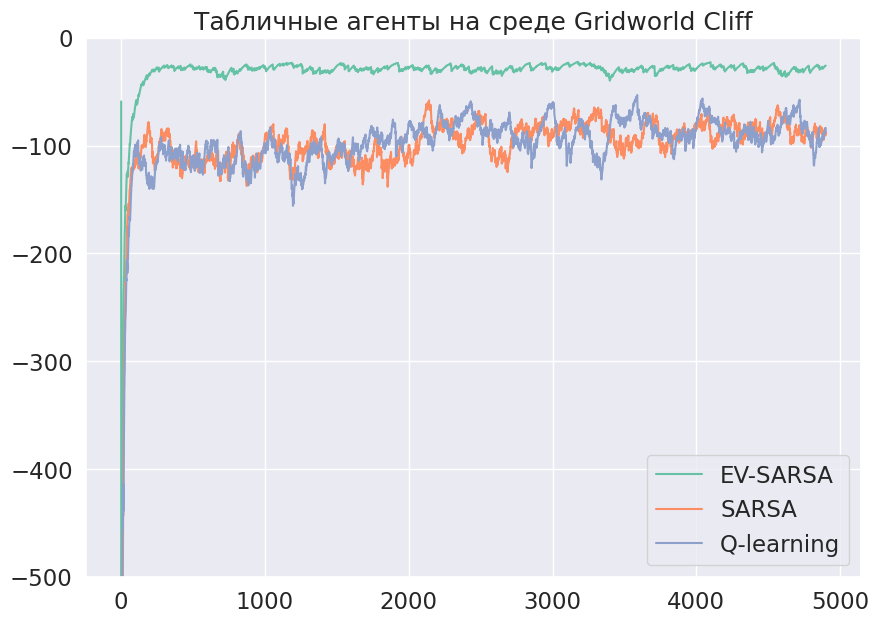

In [15]:
NUM_EPOCHS = 5000
rewards_evsarsa, rewards_sarsa, rewards_ql,  = [], [], []


for i in range(NUM_EPOCHS):
    rewards_evsarsa.append(play_and_train(env, agent_evsarsa))
    rewards_sarsa.append(play_and_train(env, agent_sarsa))
    rewards_ql.append(play_and_train(env, agent_ql))
    # Замечание: epsilon должны быть константами

    if i % 100 == 0:
        clear_output(True)

        print('EVSARSA средняя награда =', np.mean(rewards_evsarsa[-100:]))
        print('SARSA средняя награда =', np.mean(rewards_sarsa[-100:]))
        print('QLEARNING средняя награда =', np.mean(rewards_ql[-100:]))

        plt.figure(figsize=(10, 7))
        plt.title("Табличные агенты на среде Gridworld Cliff")
        plt.plot(moving_average(rewards_evsarsa), label='EV-SARSA')
        plt.plot(moving_average(rewards_sarsa), label='SARSA')
        plt.plot(moving_average(rewards_ql), label='Q-learning')
        plt.legend()
        plt.ylim(-500, 0)
        plt.show()


Посмотрим на полученные стратегии

In [16]:
def draw_policy(env, agent):
    """
    Рисует текущую политику агента

    :param env: среда cliff
    :param agent: агент
    """

    base_env = env.unwrapped
    n_rows, n_cols = base_env._cliff.shape

    terminal_state = (n_rows - 1) * n_cols + (n_cols - 1)
    actions = '^>v<'

    for yi in range(n_rows):
        for xi in range(n_cols):
            state = yi * n_cols + xi

            if base_env._cliff[yi, xi]:
                print(" C ", end='')
            elif state == base_env.start_state_index:
                print(" X ", end='')
            elif state == terminal_state:
                print(" T ", end='')
            else:
                print(f" {actions[agent.get_best_action(state)]} ", end='')
        print()

In [17]:
print("Q-Learning")
draw_policy(env, agent_ql)

print("SARSA")
draw_policy(env, agent_sarsa)

print("EVSARSA")
draw_policy(env, agent_evsarsa)

Q-Learning
 v  >  >  >  v  >  >  >  >  >  >  v 
 >  >  >  >  >  >  >  >  >  >  >  v 
 >  >  >  >  >  >  >  >  >  >  >  v 
 X  C  C  C  C  C  C  C  C  C  C  T 
SARSA
 v  v  v  >  v  >  >  v  >  v  >  v 
 >  >  >  >  >  >  >  >  >  >  >  v 
 >  >  >  >  >  >  >  >  >  >  >  v 
 X  C  C  C  C  C  C  C  C  C  C  T 
EVSARSA
 >  >  >  >  >  >  >  >  >  >  >  v 
 ^  ^  ^  >  >  >  >  >  >  >  >  v 
 ^  ^  ^  ^  ^  ^  ^  ^  ^  ^  >  v 
 X  C  C  C  C  C  C  C  C  C  C  T 


__Вопрос:__ какой агент справился хуже всего с данной игрой? Почему? Опишите подробно, почему этот эффект возникает в данной игре.

*Hint:* К какой группе относятся лучшие агенты и к какой группе относится проигравший агент? Какие свойства есть у одной группы, но отсутсвуют у другой?

Лучше справился алгоритм EVSARSA. Вероятно это не следствие самой игры, а $\epsilon$-greedy алгоритма. Алгоритмы SARSA и Q-Learning игнорируют риск упасть яму, что и не позволяет им добиться высокого суммарного реварда, в то время как EVSARSA учитывает этот риск, поэтому старается держаться вверху.

#### 3.3 Подходы к выбору действия

1). В данной секции посмотрите, как ведет себя EVSARSA на среде Gridworld Cliff с разным $\varepsilon$ в epsilon-greedy стратегии выбора действия. Посмотрите на
- большой константный $\varepsilon$;
- средний константный $\varepsilon$;
- маленький константный $\varepsilon$;
- изменяющийся $\varepsilon$.

Какой $\varepsilon$ оказался лучше всех?

2). Реализуйте softmax подход для выбора действий для EVSARSA. Попробуйте сравнить наилучший подход в epsilon-greedy стратегии с уменьшающейся температурой в softmax стратегии.

In [18]:
def experiment_evsarsa_epsilon_softmax(env, n_actions, NUM_EPOCHS=5000):
    epsilons = {
        'big': 0.5,
        'medium': 0.2,
        'small': 0.05,
        'decay': 0.5
    }

    rewards = {eps: [] for eps in epsilons}
    rewards['softmax_decay'] = []

    agents = {}
    for eps_name, eps_val in epsilons.items():
        agents[eps_name] = EVSarsaAgent(
            alpha=0.25, epsilon=eps_val, discount=0.99, n_actions=n_actions
        )

    tau_init = 0.5
    tau_decay = 0.995
    agent_softmax = EVSarsaAgent(
        alpha=0.25, epsilon=0.0, discount=0.99, n_actions=n_actions
    )
    tau = tau_init

    colors = {'big': 'r', 'medium': 'g', 'small': 'b', 'decay': 'm', 'softmax_decay': 'purple'}

    def moving_average(x, window=50):
        return np.convolve(x, np.ones(window)/window, mode='valid')

    for i in range(NUM_EPOCHS):
        for eps_name, agent in agents.items():
            rewards[eps_name].append(play_and_train(env, agent))
            if eps_name == 'decay':
                agent.epsilon *= 0.995

        rewards['softmax_decay'].append(play_and_train(env, agent_softmax, use_softmax=True, tau=tau))
        tau *= tau_decay

        if i % 500 == 0:
            clear_output(True)
            print(f"Эпизод {i}/{NUM_EPOCHS}")
            for eps_name in list(epsilons.keys()) + ['softmax_decay']:
                recent_avg = np.mean(rewards[eps_name][-100:])
                print(f"{eps_name}: средняя награда = {recent_avg:.2f}")

    plt.figure(figsize=(12, 7))
    plt.title("EVSARSA: влияние стратегии выбора действий")
    plt.ylabel("Награда")
    plt.xlabel("Эпизод")

    for name, color in colors.items():
        ma = moving_average(rewards[name])
        plt.plot(ma, color=color, label=name)

    plt.legend()
    plt.ylim(-200, 0)
    plt.show()

    return rewards, agents, agent_softmax

Эпизод 4500/5000
big: средняя награда = -86.78
medium: средняя награда = -28.01
small: средняя награда = -19.09
decay: средняя награда = -15.00
softmax_decay: средняя награда = -13.00


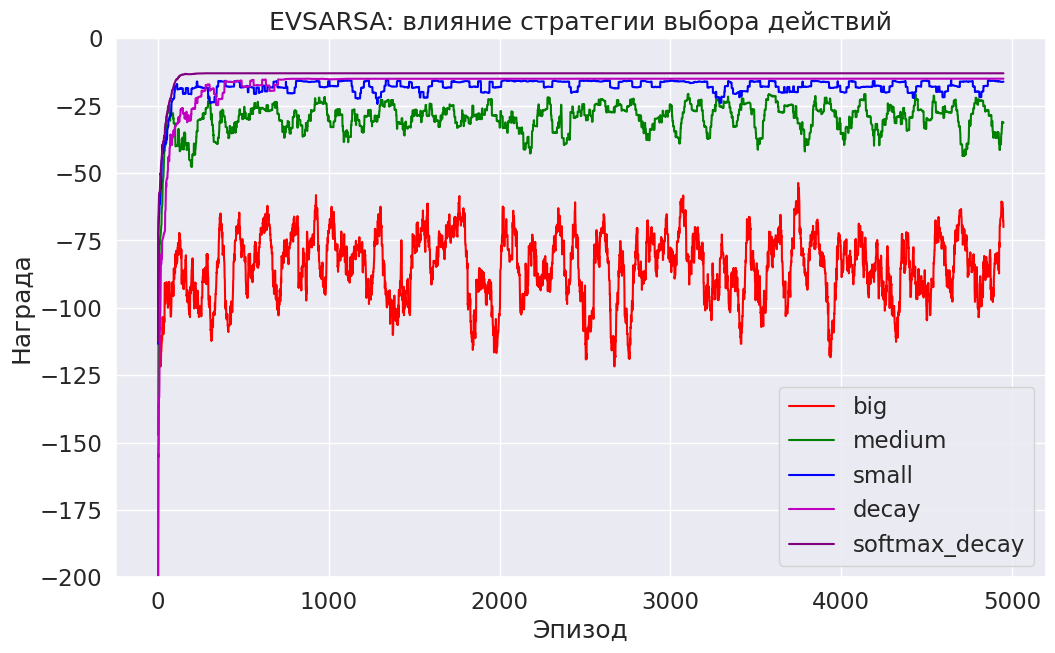

In [19]:
experiment_evsarsa_epsilon_softmax(env, 4);

Затухающий epsilon ожидаемо оказался лучше, так как после того как агент нашел оптимальный маршрут нет смысла продолжать исследования.

В силу большего затухания, использование softmax с затухающей температурой оказалось наиболее эффективно.

#### 3.4 Experience replay

Ваша задача написать Experience replay buffer.

Напомним, как выгдялит алгоритм обучения агента.
В Train цикле:

1). обучаем агента на только что сыгранной игре;

2). добавляем в replay buffer текущие увиденные состояния;

3). если очередь больше некоторого фиксированного размера $N$, удаляем вытесненные наиболее старые состояния;

4). обучаем агента на семплированных из replay buffer $(s, a, r, \widetilde{s})$ кортежах.

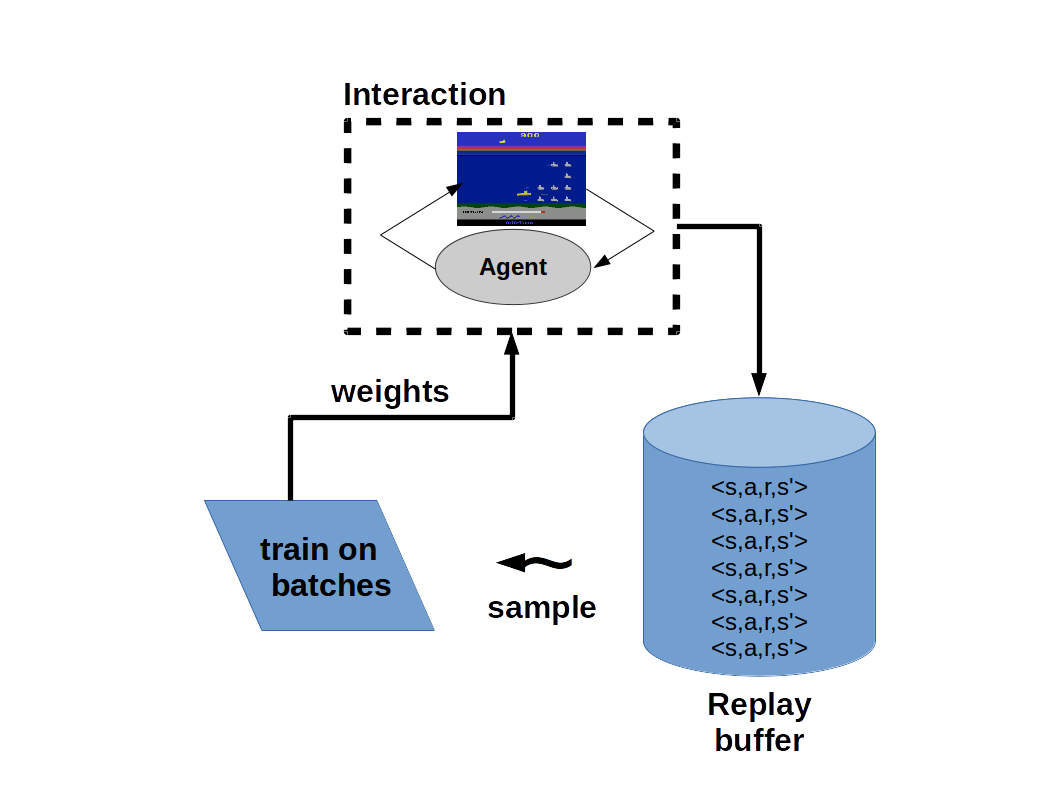

In [20]:
class ReplayBuffer(object):
    def __init__(self, size):
        """
        Создает ReplayBuffer

        :param size: максимальный размер очереди
        """

        self._storage = deque(maxlen=size)
        self._maxsize = size

    def __len__(self):
        return len(self._storage)

    def add(self, state, action, reward, state_next, done):
        """
        Добавляет новый элемент (state, action, reward, state_next, done) в очередь.
        Если очередь переполнена, то удаляет наиболее старый объект.

        :param state: состояние среды
        :param action: действие (индекс)
        :param reward: награда
        :param next_state: следующее состояние
        :param is_done: финальное ли состояние next_state
        """

        self._storage.append((state, action, reward, state_next, done))

    def sample(self, batch_size):
        """
        Отсемплировать batch_size объектов из очереди.

        :param batch_size: сколько объектов надо отдать
        :return: (states, actions, rewards, states_next, done_array),
                каждый массив размера batch_size
        """
        idxs = np.random.choice(len(self._storage), size=batch_size, replace=False)
        states = np.array([self._storage[i][0] for i in idxs])
        actions = np.array([self._storage[i][1] for i in idxs])
        rewards = np.array([self._storage[i][2] for i in idxs])
        states_next = np.array([self._storage[i][3] for i in idxs])
        done_array = np.array([self._storage[i][4] for i in idxs])

        return states, actions, rewards, states_next, done_array

In [21]:
def play_and_train_with_replay(
    env, agent, replay=None, t_max=10**4, replay_batch_size=32, need_array=False
):
    """
    Функция для сыграния агентом одной игры в env и обучения во время игры агента.
    Возвращает итоговую награду агента в текущей сессии.

    :param env: среда gymnasium
    :param agent: агент
    :param replay: None, если не надо использовать Experience replay buffer,
                   либо объект типа ReplayBuffer
    :param t_max: максимальное количество действий
    :param replay_batch_size: размер batch_size для ReplayBuffer
    :param need_array:
        False для табличных агентов (то есть ему нужно передать значения по отдельности),
        True для нейронок, так как они получаеют на вход массив состояний

    :return: total_reward - итоговая награда агента в среде
    """
    total_reward = 0.0
    s, _ = env.reset()

    for t in range(t_max):
        a = agent.get_action(s)
        next_s, r, done, _, _ = env.step(a)

        if not need_array:
            agent.update(s, a, r, next_s, done)
        else:
            agent.update([s], [a], [r], [next_s], [done])

        if replay is not None:
            replay.add(s, a, r, next_s, done)
            batch_size = min(replay_batch_size, len(replay))
            states, actions, rewards, next_states, is_done = replay.sample(batch_size)

            if not need_array:
                for tmp_s, tmp_a, tmp_r, tmp_next_s, tmp_done in zip(
                    states, actions, rewards, next_states, is_done
                ):
                    agent.update(tmp_s, tmp_a, tmp_r, tmp_next_s, tmp_done)
            else:
                s_, a_, r_, next_s_, done_ = (
                    states,
                    actions,
                    rewards,
                    next_states,
                    is_done,
                )
                agent.update(s_, a_, r_, next_s_, done_)

        s = next_s
        total_reward += r
        if done:
            break

    return total_reward

Теперь проверим его работу на среде Taxi-v3.

In [22]:
env = gym.make("Taxi-v3", render_mode='ansi')
n_actions = env.action_space.n

Посмотрим, как влияет experience replay на обучение агента.

In [23]:
agent_baseline = QLearningAgent(alpha=0.5, epsilon=0.25, discount=0.99,
                                n_actions=n_actions)

agent_replay = QLearningAgent(alpha=0.5, epsilon=0.25, discount=0.99,
                              n_actions=n_actions)

replay = ReplayBuffer(1000)

Baseline : eps = 0.0 средняя награда = 8.5
ExpReplay: eps = 0.0 средняя награда = 6.9


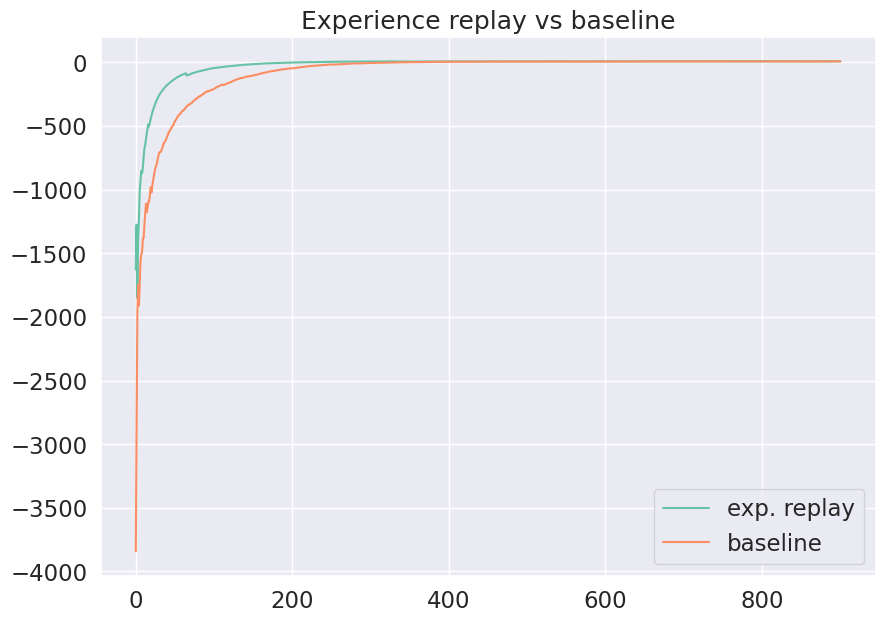

In [24]:
rewards_replay, rewards_baseline = [], []

for i in range(1000):
    rewards_replay.append(play_and_train_with_replay(env, agent_replay, replay))
    rewards_baseline.append(
        play_and_train_with_replay(env, agent_baseline, replay=None)
    )

    agent_replay.epsilon *= 0.99
    agent_baseline.epsilon *= 0.99

    if i % 100 == 0:
        clear_output(True)
        print(
            "Baseline : eps =",
            round(agent_replay.epsilon, 3),
            "средняя награда =",
            np.mean(rewards_baseline[-10:]),
        )
        print(
            "ExpReplay: eps =",
            round(agent_baseline.epsilon, 3),
            "средняя награда =",
            np.mean(rewards_replay[-10:]),
        )
        plt.figure(figsize=(10, 7))
        plt.title("Experience replay vs baseline")
        plt.plot(moving_average(rewards_replay), label="exp. replay")
        plt.plot(moving_average(rewards_baseline), label="baseline")
        plt.legend()
        plt.show()

Что можно сказать о результате сравнения? Как повлиял Experience replay?

Ожидаемо, переиспользование игр позволило нашему агенту обучиться значительно быстрее. Тем не менее на итоговое качество буффер никак не повлиял.

#### 3.5 Нейронные сети для агентов Sarsa, Q-learning и EVSARSA



Теперь ваша цель написать и обучить нейронных агентов на CartPole-v0.

In [25]:
env = gym.make("CartPole-v0").env
env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape

/home/alexander/.venv/lib/python3.13/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


__Напоминание:__

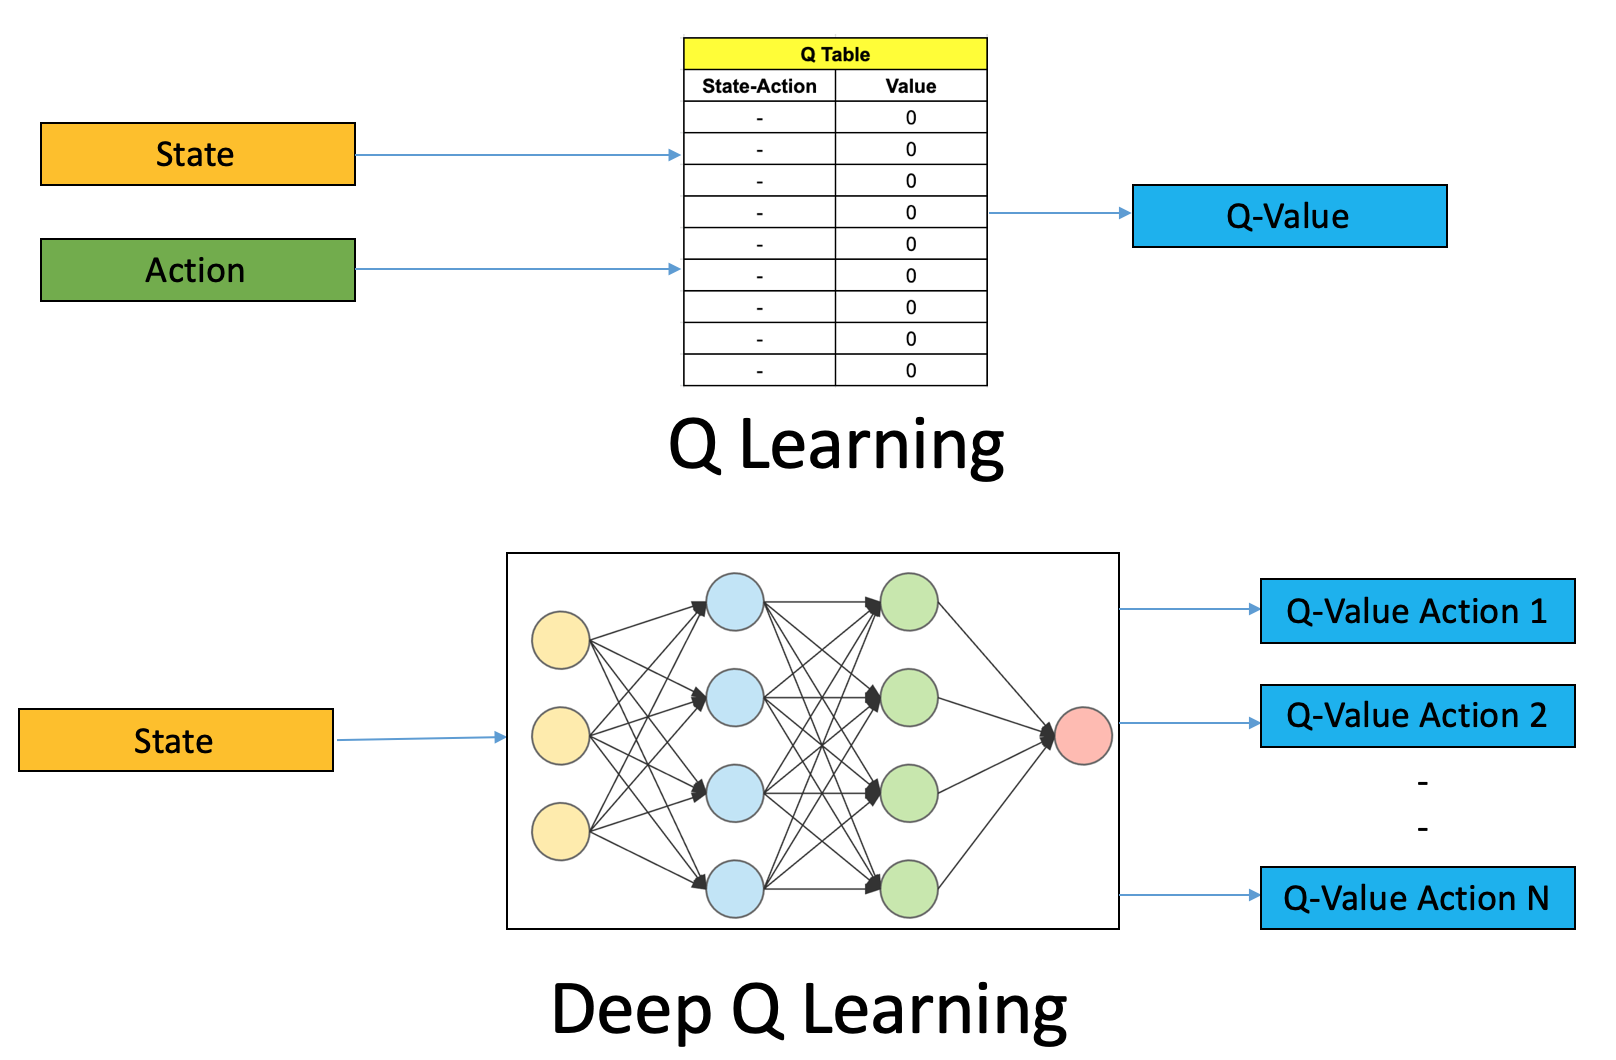

На рисунке изображено напоминание, как должен выглядеть выход из нейронной сети.

Оптимизируемый лосс для нейронных агентов:

$$
    L = (r_t + \gamma V'(s_{t + 1}) - Q(s_t, a_t))^2,
$$

Где $V'$ &mdash; __константное__ значение, чьи веса нейронная сеть не должна обновлять.

$\alpha$ параметр будет отвечать за шаг градиентного спуска.

Ваша задача написать функции `get_action`, `get_qvalues` наподобие этих функций у `AgentClass`, и `update`. Еще надо учесть, что на вход нейронному классу в каждой функции подаются массивы, что отличается от входных значений в `AgentClass`. Также не забудьте про BackProp в функции `update`.

In [26]:
class NeuralAgentClass:
    def __init__(
        self,
        space_dim,
        epsilon,
        discount,
        n_actions,
        hid_size=64,
        optimizer=torch.optim.Adam,
        lr=1e-4,
    ):
        """
        Инициализация нейронного агента

        :param space_dim: размерность пространства состояний
        :param epsilon: для epsilon-greedy стратегии
        :param discount: гамма в функции награды,
                         с каким весом оценивает будущие награды агент
        :param n_actions: количество возможных действий
        :param hid_size: размерность промежуточных слоев нейронки
        :param optimizer: класс оптимизатора
        :param lr: learning rate
        """

        self.n_actions = n_actions
        self.epsilon = epsilon
        self.discount = discount
        # Нейронная сеть не должна быть глубокой, достаточно 2-3 линейных слоев.
        self.network = nn.Sequential(
            nn.Linear(space_dim, hid_size), nn.ReLU(), nn.Linear(hid_size, n_actions)
        )
        self.optimizer = optimizer(self.network.parameters(), lr=lr)

    def get_action(self, state):
        """
        Функция для выбора действия для состояния state, которое совершит агент
        исходя из epsilon-greedy стратегии.
        С вероятностью 1-epsilon он должен вернуть действие, максимизирующее Q,
        c вероятностью epsilon вернуть любое действие.

        :param state: текущее состояние

        :return: action - индекс действия
        """

        if np.random.random() < 1 - self.epsilon:
            state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
            qvals = self.network(state_tensor)
            qvals = qvals.detach().numpy()[0]
            return np.argmax(qvals)
        else:
            return np.random.randint(0, self.n_actions)

    def get_values(self, states):
        """
        Своя функция для каждого из алгоритмов.

        :param state: состояние среды

        :return: оценка V(s)
        """

        raise Exception("Not implemented")

    def get_qvalues(self, states, actions):
        """
        Возвращает массив Q(states, actions).
        Нейрнонная сеть вернет все Q значения для каждого state в массиве,
        вам нужно взять лишь одно.

        :param states: массив состояний,
                       для каждого из которых нужно подобрать действие
        :param actions: массив дейсвий

        :return: q_values_array - значения Q для каждой пары state, action.
        """

        q_all = self.network(states)
        q_vals = q_all.gather(1, actions.unsqueeze(1)).squeeze(1)
        return q_vals

    def update(self, states, actions, rewards, next_states, is_done):
        """
        Loss = (r_t + \gamma V(s_{t + 1})_const - Q(s_t, a_t))^2
        Подсказка:
        реализуйте по частям
        1) Q(s_t, a_t)
        2) next state values
        3) TD_target
        (можете посмотреть на семинаре, если не помните, что это)
        4) loss
        5) backpropagation

        Важно не забыть:
        1) V(s_{t + 1}) - константа
        2) TD_target отличается, если next_states - финальное состояние среды.
        Вам может помочь torch.where(is_done, ...)

        :param states: массив состояний среды
        :param actions: массив действий (индексы)
        :param rewards: награды
        :param next_states: следующие состояния
        :param is_done: финальные ли состояния next_state
        """

        gamma = self.discount
        states = torch.tensor(
            states, dtype=torch.float32
        )  # shape: [batch_size, state_size]
        actions = torch.tensor(actions, dtype=torch.long)  # shape: [batch_size]
        rewards = torch.tensor(rewards, dtype=torch.float32)  # shape: [batch_size]
        next_states = torch.tensor(
            next_states, dtype=torch.float32
        )  # shape: [batch_size, state_size]
        is_done = torch.tensor(is_done, dtype=torch.uint8)  # shape: [batch_size]

        # 1)
        Q_vals = self.get_qvalues(states, actions)

        # 2)
        with torch.no_grad():
            next_state_values = self.get_values(next_states)

        # 3)
        TD = rewards + (gamma * next_state_values) * (1 - is_done)

        # 4)
        loss = ((TD - Q_vals) ** 2).mean()

        # 5)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def get_best_action(self, states):
        states_tensor = torch.tensor(states, dtype=torch.float32)
        if states_tensor.ndim == 1:
            states_tensor = states_tensor.unsqueeze(0)
        qvals = self.network(states_tensor)
        best_actions = torch.argmax(qvals, dim=1)
        return best_actions

    def policy(self, states, actions):
        best_actions = self.get_best_action(states)
        actions = torch.tensor(actions)
        probs = (1 - self.epsilon) * (actions == best_actions).float() + self.epsilon / self.n_actions
        return probs

<>:84: SyntaxWarning: invalid escape sequence '\g'
<>:84: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_2758/183713961.py:84: SyntaxWarning: invalid escape sequence '\g'
  Loss = (r_t + \gamma V(s_{t + 1})_const - Q(s_t, a_t))^2


Теперь реализуйте 3 агентов Sarsa, Q-learning и EVSARSA в случае, когда базовый класс это `NeuralAgentClass`. Также попробуйте по памяти написать, как выглядят формулы пересчета `get_value`, не подглядывая в формулы, написанные ранее. Не забудьте, что они должны работать с массивами.

In [27]:
class NeuralSarsaAgent(NeuralAgentClass):
    def get_values(self, states):
        """
        :param states: массив состояний среды
        :return: оценка V(s)
        """
        actions = self.get_best_action(states)
        return self.get_qvalues(states, actions)

In [28]:
class NeuralEVSarsaAgent(NeuralAgentClass):
    def get_values(self, states):
        """
        :param states: массив состояний среды
        :return: оценка V(s)
        """
        batch_size = states.shape[0]

        q_all = torch.stack(
            [
                self.get_qvalues(states, torch.full((batch_size,), a, dtype=torch.long))
                for a in range(self.n_actions)
            ],
            dim=1,
        )

        best_actions = self.get_best_action(states)  # Уже тензор
        actions_arr = torch.arange(self.n_actions).unsqueeze(0).repeat(batch_size, 1)
        probs = (actions_arr == best_actions.unsqueeze(1)).float() * (
            1 - self.epsilon
        ) + self.epsilon / self.n_actions

        return torch.sum(probs * q_all, dim=1)

In [29]:
class NeuralQlearning(NeuralAgentClass):
    def get_values(self, states):
        """
        :param states: массив состояний среды
        :return: оценка V(s)
        """
        batch_size = states.shape[0]

        q_all = torch.stack(
            [
                self.get_qvalues(states, torch.full((batch_size,), a, dtype=torch.long))
                for a in range(self.n_actions)
            ],
            dim=1,
        )

        return torch.max(q_all, dim=1).values

Проверим, что `NeuralAgentClass` не падает:

In [30]:
# sanity checks
net_evsarsa = NeuralEVSarsaAgent(state_dim[0], epsilon=0,
                                 discount=0.99, n_actions=n_actions)
s, _ = env.reset()
a = env.action_space.sample()
next_s, r, done, _, _ = env.step(a)
net_evsarsa.update([s], [a], [r], [next_s], [done])

/tmp/ipykernel_2758/183713961.py:107: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  states = torch.tensor(
/tmp/ipykernel_2758/183713961.py:136: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  states_tensor = torch.tensor(states, dtype=torch.float32)


Теперь ваша задача выбить +300 очков каждым из агентов. Советуем запускать Q-learning отдельно от остальных агентов.

В авторском коде на CPU агенты обучаются примерно за 20 минут.

In [31]:
# sanity checks
neural_sarsa = NeuralSarsaAgent(state_dim[0], epsilon=0.8,
                                discount=0.99, n_actions=n_actions)
neural_evsarsa = NeuralEVSarsaAgent(state_dim[0], epsilon=0.8,
                                    discount=0.99, n_actions=n_actions)
replay_sarsa = ReplayBuffer(1000)
replay_evsarsa = ReplayBuffer(1000)

В коде обучения моделей кое-что пропущено, что может увеличить время обучения агентов, будьте внимательны.

Neural SARSA:   eps = 0.415	средняя награда = 343.99
Neural EVSARSA: eps = 0.415	средняя награда = 337.96


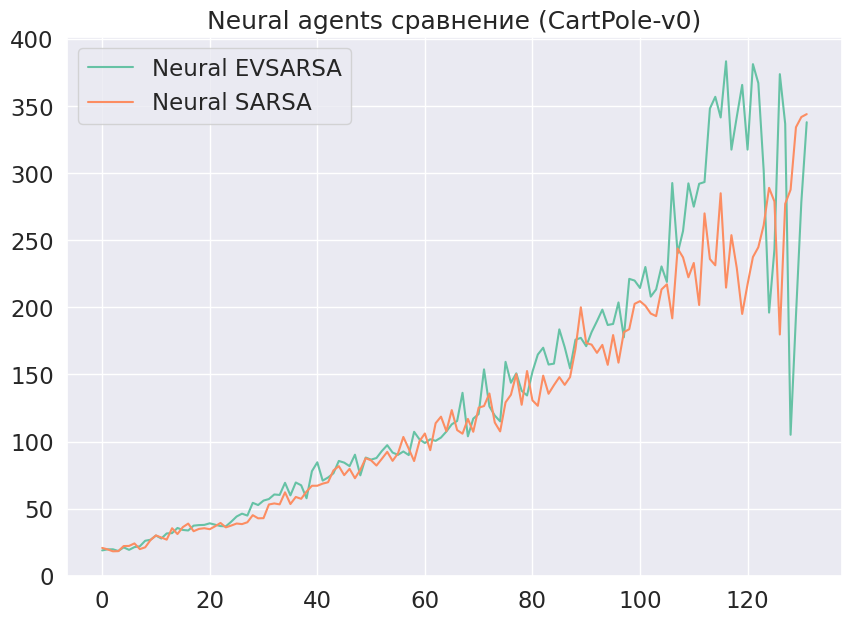

You Win!


In [32]:
neural_sarsa_rewards_history = []
neural_evsarsa_rewards_history = []

while True:
    # Обучение вместе с experience replay
    neural_sarsa_session_rewards = [
        play_and_train_with_replay(env, neural_sarsa, replay=replay_sarsa,
                                   replay_batch_size=8, need_array=True)
        for _ in range(100)
    ]
    neural_evsarsa_session_rewards = [
        play_and_train_with_replay(env, neural_evsarsa, replay=replay_evsarsa,
                                   replay_batch_size=8, need_array=True)
        for _ in range(100)
    ]

    gc.collect()
    clear_output(True)

    # Текущие результаты
    print(f'Neural SARSA:   eps = {neural_sarsa.epsilon:.3f}\t'
          f'средняя награда = {np.mean(neural_sarsa_session_rewards):.2f}')
    print(f'Neural EVSARSA: eps = {neural_evsarsa.epsilon:.3f}\t'
          f'средняя награда = {np.mean(neural_evsarsa_session_rewards):.2f}')

    # Сохранение результатов
    neural_sarsa_rewards_history.append(np.mean(neural_sarsa_session_rewards))
    neural_evsarsa_rewards_history.append(np.mean(neural_evsarsa_session_rewards))

    # Визуализация
    plt.figure(figsize=(10, 7))
    plt.title("Neural agents сравнение (CartPole-v0)")
    plt.plot(neural_evsarsa_rewards_history, label='Neural EVSARSA')
    plt.plot(neural_sarsa_rewards_history, label='Neural SARSA')
    plt.legend()
    plt.show()

    # Условие выхода из цикла
    if neural_sarsa_rewards_history[-1] > 300 \
       and neural_evsarsa_rewards_history[-1] > 300:
        print("You Win!")
        break

    neural_sarsa.epsilon = max(0.01, neural_sarsa.epsilon * 0.995)
    neural_evsarsa.epsilon = max(0.01, neural_evsarsa.epsilon * 0.995)

Q-learning в какой-то момент может сильно упасть в качестве из-за большого epsilon, но в итоге все равно должен побить порог.

In [33]:
neural_qlearning = NeuralQlearning(state_dim[0], epsilon=0.8,
                                   discount=0.99, n_actions=n_actions)
replay_qlearning = ReplayBuffer(1000)

Neural Q-learning: eps = 0.407	средняя награда = 300.19


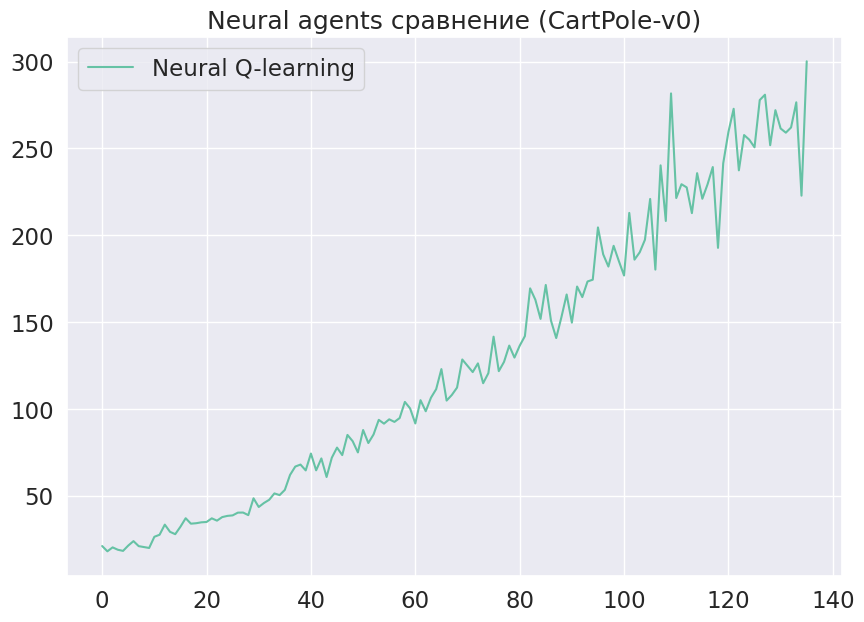

You Win!


In [34]:
neural_qlearning_rewards_history = []

while True:
    # Обучение вместе с experience replay
    neural_qlearning_rewards = [
        play_and_train_with_replay(env, neural_qlearning,
                                   replay=replay_qlearning,
                                   replay_batch_size=8, need_array=True)
        for _ in range(100)
    ]

    gc.collect()
    clear_output(True)
    # Текущие результаты
    print(f'Neural Q-learning: eps = {neural_qlearning.epsilon:.3f}\t'
          f'средняя награда = {np.mean(neural_qlearning_rewards):.2f}')

    # Сохранение результатов
    neural_qlearning_rewards_history.append(np.mean(neural_qlearning_rewards))

    plt.figure(figsize=(10, 7))
    plt.title("Neural agents сравнение (CartPole-v0)")
    plt.plot(neural_qlearning_rewards_history, label='Neural Q-learning')
    plt.legend()
    plt.show()

    # Условие выхода из цикла
    if neural_qlearning_rewards_history[-1] > 300:
        print("You Win!")
        break
    neural_qlearning.epsilon = max(0.01, neural_qlearning.epsilon * 0.995)

Теперь изобразим все 3 кривые обучения на одном графике.

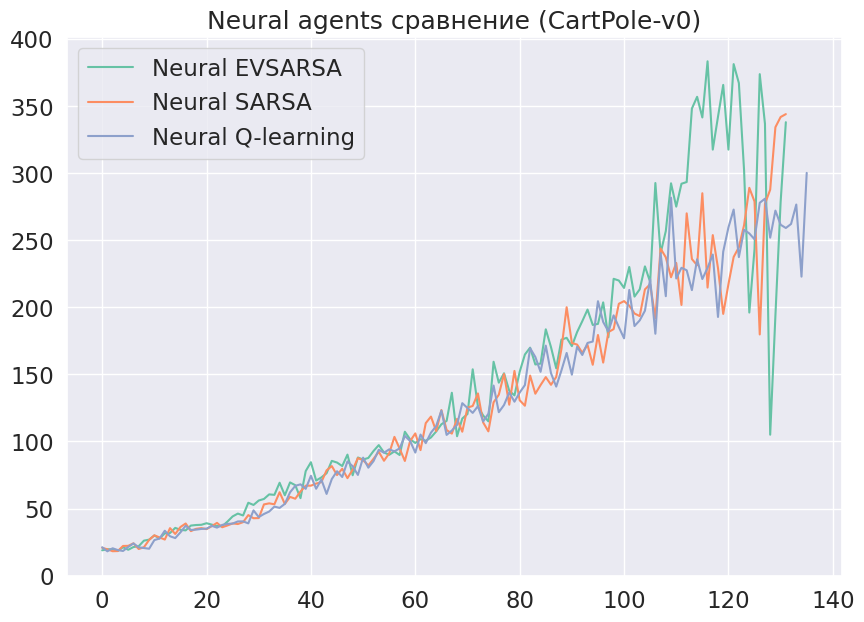

In [35]:
plt.figure(figsize=(10, 7))
plt.title("Neural agents сравнение (CartPole-v0)")
plt.plot(neural_evsarsa_rewards_history, label='Neural EVSARSA')
plt.plot(neural_sarsa_rewards_history, label='Neural SARSA')
plt.plot(neural_qlearning_rewards_history, label='Neural Q-learning')
plt.legend()
plt.show()

Что вы можете сказать о результатах? Сравните их с результатами табличных агентов на бинаризированной среде.

**Выводы:** Мы видим, что нейросетевые агенты обучаются значительно дольше табличных. У меня, как видно под конец дисперсия нейросетевых агентов сильно подскачила, возможно из-за того что $\varepsilon$ оставался высоким. Также очевидно, что нейросетевые агенты справляются намного лучше с большим пространством действий и состояний, в силу того, что им не нужно хранить огромную таблицу.

